In [1]:
import argparse
import os
import sys
import time

import basix
import dolfinx
import matplotlib.pyplot as plt
import numpy as np
import scifem
import ufl

from dolfinx import fem, mesh

from dolfinx.cpp.mesh import cell_num_entities

from dolfinx.fem.petsc import assemble_matrix_block, assemble_vector_block, NonlinearProblem
from dolfinx.geometry import bb_tree, compute_collisions_points, compute_colliding_cells
from dolfinx.io import gmshio, VTXWriter
from dolfinx.nls import petsc as petsc_nls
from mpi4py import MPI
from petsc4py import PETSc
from ufl import avg, div, dot, grad, inner, jump

import commons, mesh_utils, solver_params, solvers, utils

In [2]:
params = {
    # 'text.usetex': True,
    'figure.figsize': (5, 4.5),
    'font.size' : 12,
    'font.family': 'monospace',
    'axes.labelsize': 12,
    'lines.linewidth': 1.0,
    'legend.fontsize': 12,
    'xtick.direction': "in",
    'xtick.top': True,
    'xtick.minor.visible': True,
    'ytick.direction': "in",
    'ytick.minor.visible': True,
    'ytick.right': True,
    'savefig.format': 'eps',
}
plt.rcParams.update(params)

In [3]:
faraday_const = 96485
R = 8.3145
T = 298
a = 100
i0 = 10
kappa = 4

alpha = 0.5
V0 = 0.5
L_p = 0.02
H_p = 0.03
A_m = 0.006
V_cell = 1.0
d_p = 0.01
N_s = 100
L = N_s * d_p/2

w = 99

In [4]:
comm = MPI.COMM_WORLD
domain = mesh.create_interval(comm, 1000, [0, L])
tdim = domain.topology.dim
fdim = tdim - 1
ft_imap = domain.topology.index_map(fdim)
num_facets = ft_imap.size_local + ft_imap.num_ghosts
indices = np.arange(0, num_facets)
values = np.zeros(indices.shape, dtype=np.intc)
left_marker = 1
right_marker = 2

values[0] = left_marker
values[-1] = right_marker
ft = mesh.meshtags(domain, fdim, indices, values)

x = ufl.SpatialCoordinate(domain)
n = ufl.FacetNormal(domain)

In [5]:
def left_boundary(x):
    return np.isclose(x[0], 0)

def right_boundary(x):
    return np.isclose(x[0], 1)

In [6]:
V = fem.functionspace(domain, ("CG", 2))

In [7]:
u, v = fem.Function(V), ufl.TestFunction(V)

In [8]:
dx = ufl.Measure('dx', domain=domain)
ds = ufl.Measure('ds', domain=domain, subdomain_data=ft)

In [9]:
u_left = fem.Function(V)
u_left.x.array[:] = 0
domain.topology.create_connectivity(fdim, tdim)
left_bc = fem.dirichletbc(
    u_left, fem.locate_dofs_topological(V, fdim, ft.find(left_marker))
)

bcs = [left_bc]

In [10]:
def func_0(V=V0):
    xi = alpha * faraday_const / (R * T)
    coef = np.sqrt(2 * a * i0 / (alpha ** 2) * (kappa * R * T/faraday_const))
    return coef * (alpha * np.exp(xi * V) + alpha * np.exp(-xi*V) - 1) ** 0.5


def slope_0(V=V0):
    xi = alpha * faraday_const / (R * T)
    coef = np.sqrt(2 * a * i0 / (alpha ** 2) * (kappa * R * T/faraday_const))
    return coef * 0.5 * (-alpha * xi * np.exp(xi * V) + alpha * xi * np.exp(-xi*V)) / (-1 + alpha * np.exp(xi*V) + alpha * np.exp(-xi*V)) ** 0.5


def R_p():
    return L_p / kappa

In [11]:
R_p()

0.005

In [12]:
lambda_sq = H_p / (kappa * A_m * R_p() * (1 - 1/(slope_0() * R_p())))
source = lambda_sq * (V_cell / d_p * x[0] - func_0()/slope_0())

# N_p = 1 / (lambda_sq ** 0.5 * d_p)
# R_p = L_p / (kappa * H_p * d_p)
# R_m = d_p / (kappa * A_m)

In [13]:
F0 = -inner(kappa * grad(u), grad(v)) * dx  + (lambda_sq * u - source) * v * dx

In [14]:
F = [fem.form(F0)]
j00 = fem.form(ufl.derivative(F0, u))
J = [[j00]]

In [15]:
opts = {
            'ksp_type': 'preonly',
            'pc_type': 'lu',
            }

solver = scifem.NewtonSolver(F, J, [u], bcs=bcs, petsc_options=opts)

t0 = time.time()
solver.solve()
t1 = time.time()
PETSc.Sys.Print(f"Solve time: {t1 - t0:.3f}s")

Solve time: 0.002s


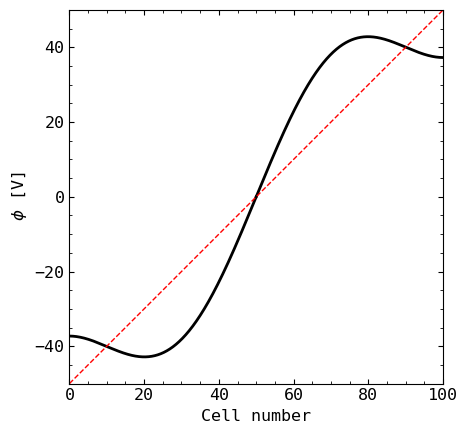

In [16]:
bb_trees = bb_tree(domain, domain.topology.dim)
n_points = 10000
tol = 1e-8  # Avoid hitting the outside of the domain
x = np.linspace(tol, L - tol, n_points)
points = np.zeros((3, n_points))
points[0] = x
u_values = []
cells = []
points_on_proc = []
cell_candidates = compute_collisions_points(bb_trees, points.T)
colliding_cells = compute_colliding_cells(domain, cell_candidates, points.T)
for i, point in enumerate(points.T):
    if len(colliding_cells.links(i)) > 0:
        points_on_proc.append(point)
        cells.append(colliding_cells.links(i)[0])
points_on_proc = np.array(points_on_proc, dtype=np.float64)
u_values = u.eval(points_on_proc, cells)
fig, ax = plt.subplots()
y = points_on_proc[:, 0] / d_p
ax.plot(y + N_s/2, u_values, "k", linewidth=2)
ax.plot(N_s/2 - y, -u_values, "k", linewidth=2)

ax.set_ylabel(r'$\phi$ [V]')
ax.set_xlabel(r'Cell number')
ax.set_ylim([-N_s/2, N_s/2])
ax.set_xlim([0, N_s])
ax.plot([0, N_s], [-N_s/2, N_s/2], 'r--')
ax.set_box_aspect(1);
ax.minorticks_on();
plt.tight_layout()
plt.show()

In [17]:
def i_p(y, phi):
    return (V_cell * y/d_p - func_0()/slope_0() - phi) / (R_p() * (1 - 1/(slope_0() * R_p())))

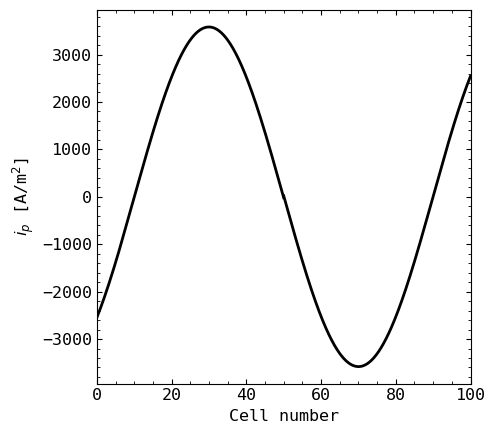

In [18]:
y = points_on_proc[:, 0]
fig, ax = plt.subplots()
ax.plot(y/d_p + N_s/2, i_p(y, u_values[:, 0]), "k", linewidth=2)
ax.plot(-y/d_p + N_s/2, -i_p(y, u_values[:, 0]), "k", linewidth=2)
ax.set_xlabel(r'Cell number')
ax.set_ylabel(r'$i_p$ [A/m$^2$]')
# ax.set_ylim([-N_s/2, N_s/2])
ax.set_xlim([0, N_s])
ax.set_box_aspect(1);
ax.minorticks_on();
plt.tight_layout()
plt.show()

In [19]:
W = fem.functionspace(domain, ("CG", 2, (1,)))
I_m = fem.Function(W)
I_m_expr = fem.Expression(-kappa * A_m * grad(u), W.element.interpolation_points())
I_m.interpolate(I_m_expr)

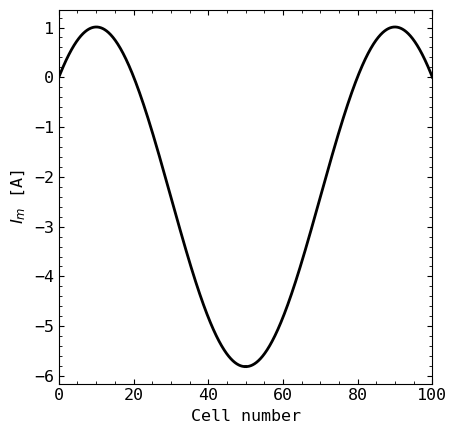

In [20]:
bb_trees = bb_tree(domain, domain.topology.dim)
n_points = 10000
tol = 1e-8  # Avoid hitting the outside of the domain
x = np.linspace(tol, L - tol, n_points)
points = np.zeros((3, n_points))
points[0] = x
I_m_values = []
cells = []
points_on_proc = []
cell_candidates = compute_collisions_points(bb_trees, points.T)
colliding_cells = compute_colliding_cells(domain, cell_candidates, points.T)
for i, point in enumerate(points.T):
    if len(colliding_cells.links(i)) > 0:
        points_on_proc.append(point)
        cells.append(colliding_cells.links(i)[0])
points_on_proc = np.array(points_on_proc, dtype=np.float64)
I_m_values = I_m.eval(points_on_proc, cells)
fig, ax = plt.subplots()
y = points_on_proc[:, 0] / d_p
ax.plot(y + N_s/2, I_m_values, "k", linewidth=2)
ax.plot(N_s/2 - y, I_m_values, "k", linewidth=2)

ax.set_ylabel(r'$I_m$ [A]')
ax.set_xlabel(r'Cell number')
ax.set_xlim([0, N_s])
ax.set_box_aspect(1);
ax.minorticks_on();
plt.tight_layout()
plt.show()